### Perform exploratory data analysis (EDA) to gain insights into the dataset. 
### Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [4]:
df.shape

(1436, 11)

In [5]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [8]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [9]:
cor=df[df.duplicated()] #checking duplicates
cor

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [10]:
df=df.drop_duplicates() #drop duplicates

In [11]:
df.duplicated().sum()

0

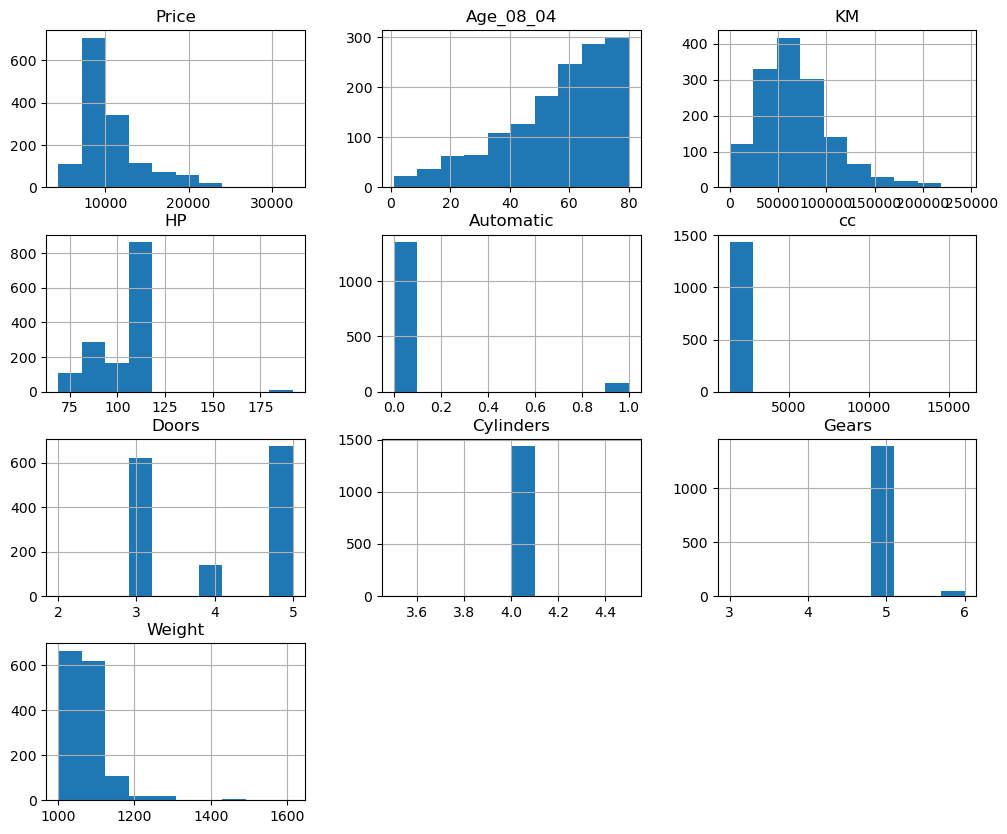

In [12]:
df.hist(figsize=(12,10))
plt.show()

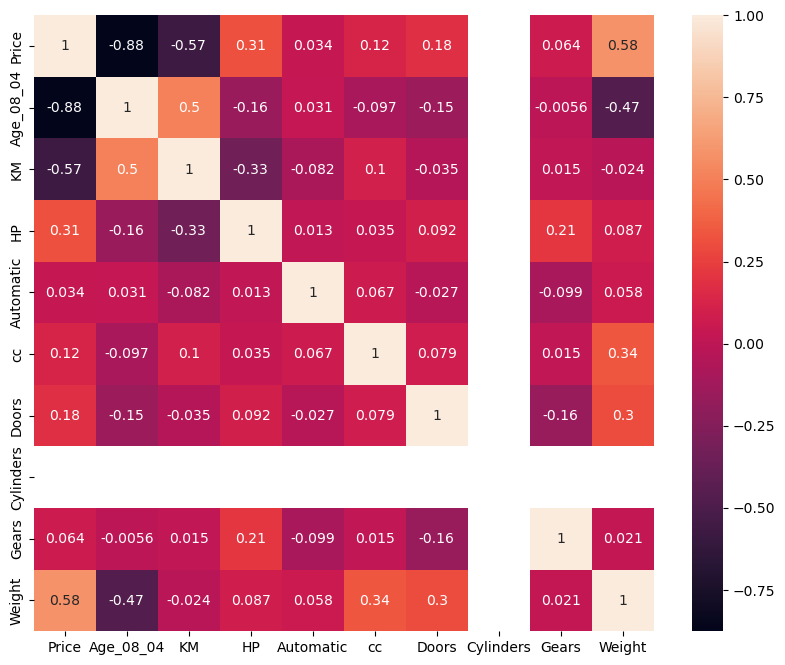

In [13]:
#correaltion of heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

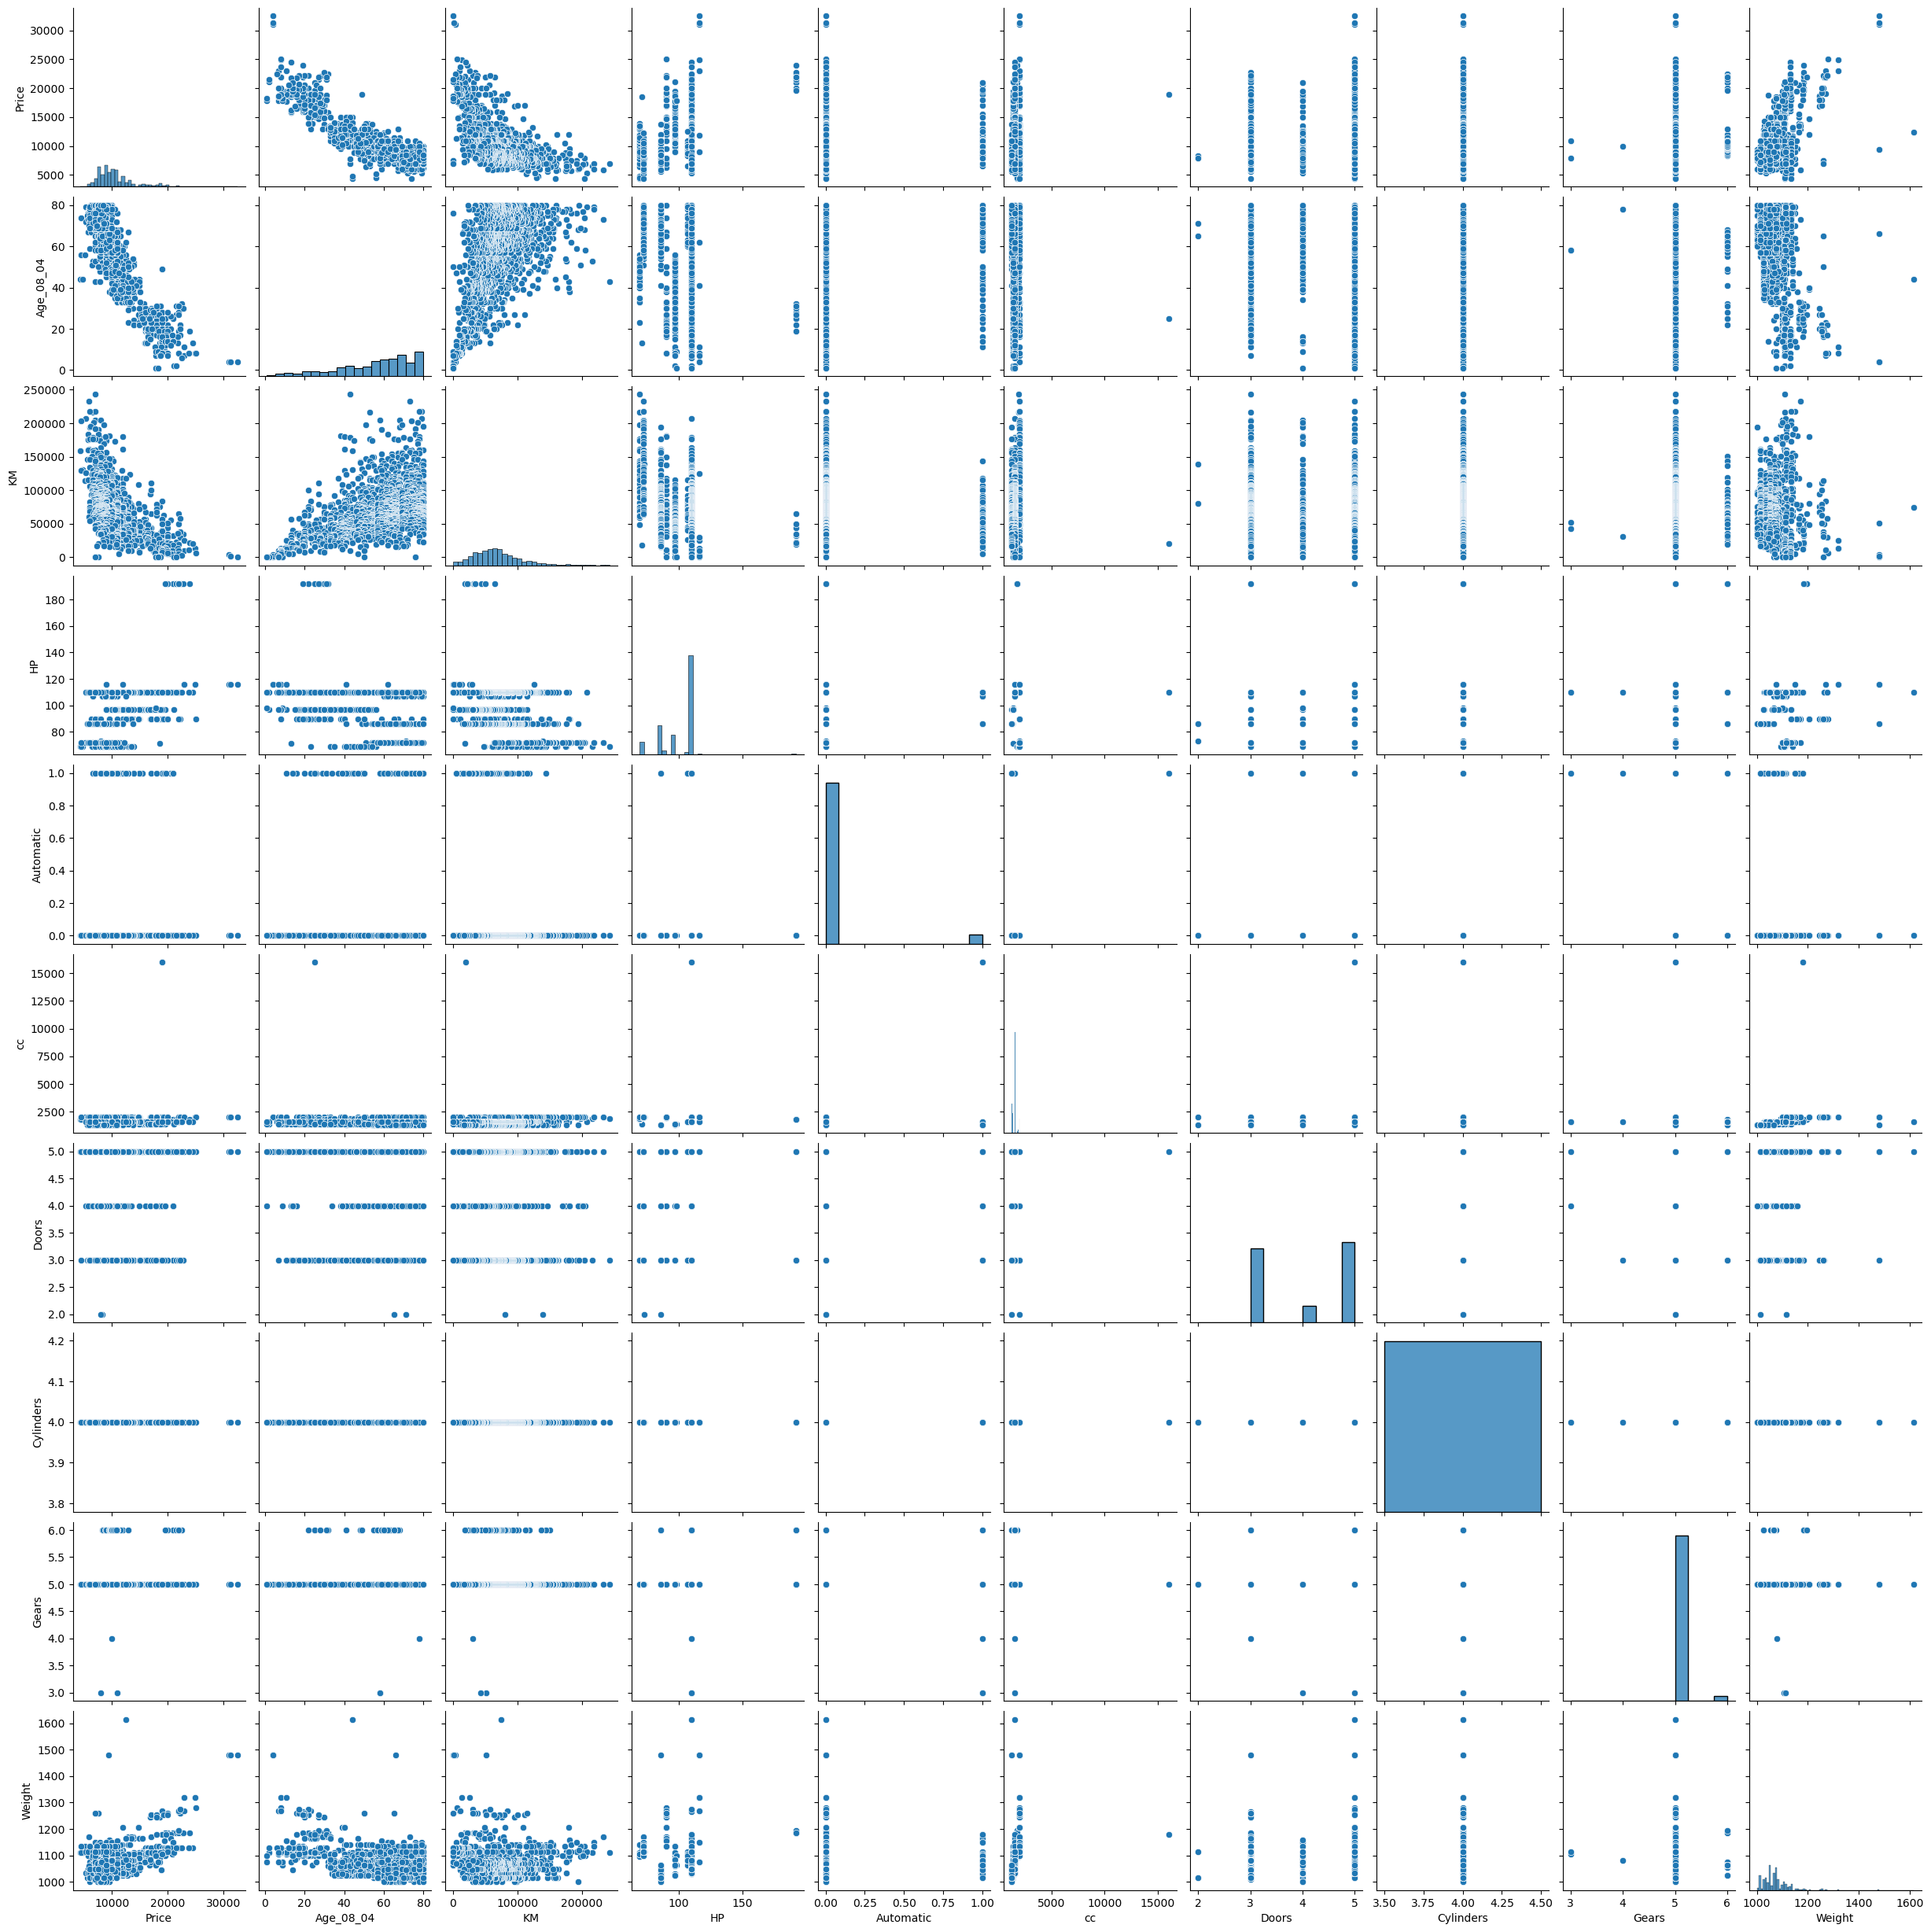

In [14]:
#pair plot
sns.pairplot(df)
plt.show()

In [15]:
#scaling the categorical columns
df = pd.get_dummies(df,columns=['Fuel_Type'],drop_first=True)

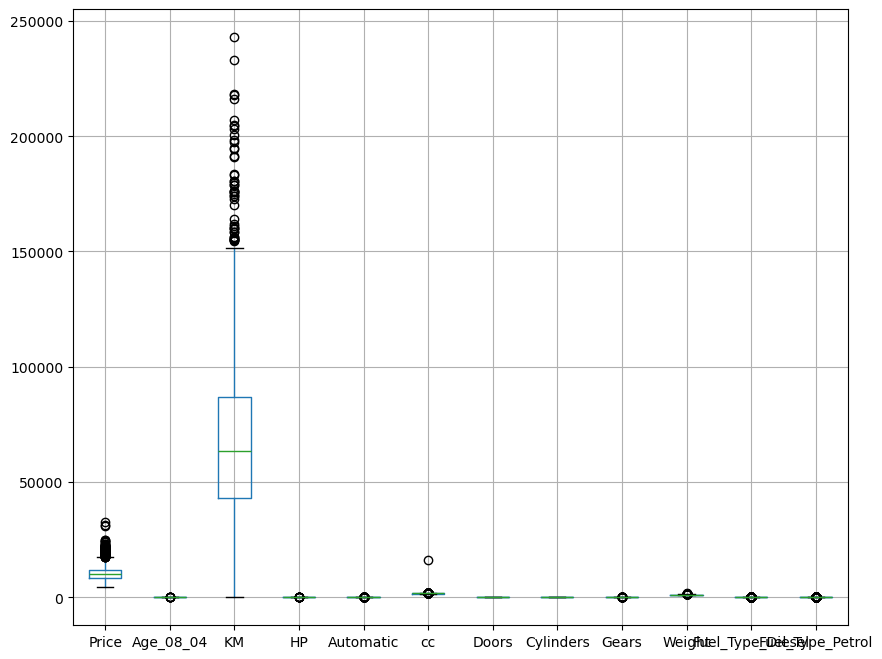

In [16]:
#checking outliers by using boxplot
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

In [17]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

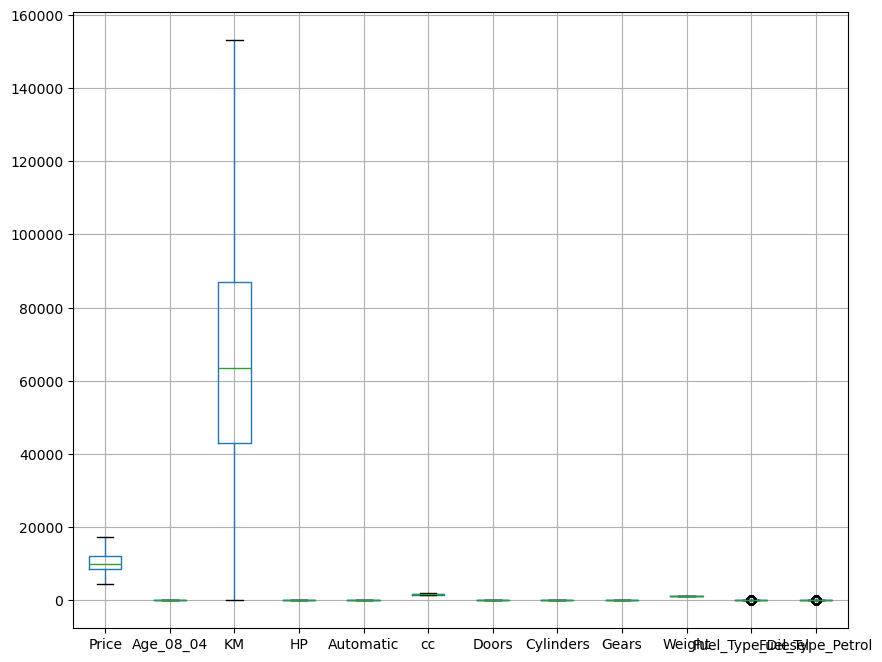

In [18]:
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

In [19]:
target=df[['Price']]
feature=df.drop(columns=['Price'])

In [20]:
feature.dtypes

Age_08_04           float64
KM                  float64
HP                  float64
Automatic           float64
cc                  float64
Doors                 int64
Cylinders             int64
Gears               float64
Weight              float64
Fuel_Type_Diesel       bool
Fuel_Type_Petrol       bool
dtype: object

In [21]:
# VIF (Variance Inflation Factor) measures multicollinearity
#VIF > 10 indicates severe multicollinearity.
#Highly correlated variables should be removed.

In [22]:
# Convert all columns into numeric type
feature_multi= feature.astype(float)

# Add constant
x_const = sm.add_constant(feature_multi)

# Create VIF dataframe
vif_data = pd.DataFrame()

vif_data['Feature'] = x_const.columns

# Calculate VIF
vif_data['VIF'] = [
    variance_inflation_factor(x_const.values, i)
    for i in range(x_const.shape[1])
]

print(vif_data)

             Feature        VIF
0          Age_08_04   2.181306
1                 KM   2.015390
2                 HP  10.104386
3          Automatic        NaN
4                 cc  12.807789
5              Doors   1.302842
6          Cylinders   0.000000
7              Gears   0.000000
8             Weight   3.853438
9   Fuel_Type_Diesel  26.769346
10  Fuel_Type_Petrol   9.692439


Text(0.5, 1.0, 'VIF Feature Analysis')

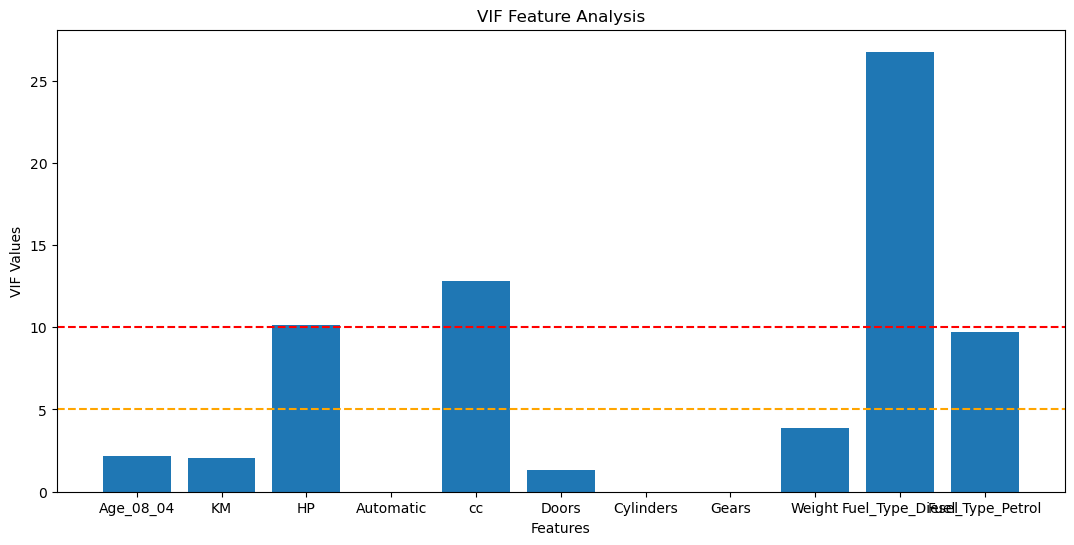

In [62]:
#vif representation for weak features identifing
plt.figure(figsize=(13,6))
plt.bar(vif_data['Feature'], vif_data['VIF'])
# Reference lines
plt.axhline(5, color='orange', linestyle='--')
plt.axhline(10, color='red', linestyle='--')

# Labels and title
plt.xlabel("Features")
plt.ylabel("VIF Values")
plt.title("VIF Feature Analysis")

### Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [23]:
x_train,x_test,y_train,y_test=train_test_split(feature,target,train_size=0.8,random_state=10)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 11)
(287, 11)
(1148, 1)
(287, 1)


In [24]:
df

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,86.0,0.0,1300.0,3,4,5.0,1025.0,False,True
1432,10845.0,72.0,19000.0,86.0,0.0,1300.0,3,4,5.0,1015.0,False,True
1433,8500.0,71.0,17016.0,86.0,0.0,1300.0,3,4,5.0,1015.0,False,True
1434,7250.0,70.0,16916.0,86.0,0.0,1300.0,3,4,5.0,1015.0,False,True


### Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [25]:
#Model1--- features

In [26]:
model_1=LinearRegression()

In [27]:
model_1.fit(x_train,y_train)

LinearRegression()

In [28]:
print('Intercept',model_1.intercept_) 
print('Slope',model_1.coef_)

Intercept [-7624.33940164]
Slope [[-1.07840995e+02 -1.39874362e-02  2.45509079e+01 -3.48165941e-13
  -2.06230123e+00 -9.73966099e+01 -5.68434189e-14 -2.27373675e-13
   2.34006674e+01  9.78952267e+02  1.26789020e+03]]


In [29]:
y_pred=model_1.predict(x_test)
model_1_mse=mean_squared_error(y_test,y_pred)
model_1_r2=r2_score(y_test,y_pred)

In [30]:
print("mse:",model_1_mse)
print("r2:",model_1_r2)

mse: 1308804.0671017028
r2: 0.862831857127946


In [68]:
# Model2--Selected Features
#weak features removed(due to multicollinearity)

In [69]:
feature2=df.drop(['Price','HP','Gears','Cylinders','Automatic','Fuel_Type_Diesel'],axis=1)
target=df[['Price']]

x_train2, x_test2, y_train2, y_test2 = train_test_split(feature2,target2, train_size=0.8, random_state=10)

In [70]:
model_2 = LinearRegression()
model_2.fit(x_train2, y_train2)

LinearRegression()

In [71]:
print('Intercept',model_2.intercept_) 
print('Slope',model_2.coef_)

Intercept [-8449.7877065]
Slope [[-1.08882965e+02 -1.44759355e-02 -2.89474139e-01 -1.01382126e+02
   2.38487507e+01  1.58278793e+03]]


In [72]:
y_pred1= model_2.predict(x_test2)

model_2_mse=mean_squared_error(y_test2,y_pred1)
model_2_r2=r2_score(y_test2,y_pred1)

In [73]:
print("mse:",model_2_mse)
print("r2:",model_2_r2)

mse: 1335495.2883171819
r2: 0.8600345054561851


In [74]:
# model3---With Feature Scaling

In [75]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(feature2)

In [76]:
pd.DataFrame(x_train_scaled,columns=feature2.columns)

,Age_08_04,KM,cc,Doors,Weight,Fuel_Type_Petrol
0,-1.781129,-0.595118,2.024972,-1.084443,2.226997,-2.718789
1,-1.781129,0.152463,2.024972,-1.084443,2.226997,-2.718789
2,-1.727143,-0.747078,2.024972,-1.084443,2.226997,-2.718789
3,-1.619171,-0.565908,2.024972,-1.084443,2.226997,-2.718789
4,-1.403226,-0.839578,2.024972,-1.084443,2.226997,-2.718789
...,...,...,...,...,...,...
1430,0.702234,-1.356844,-1.531016,-1.084443,-1.154108,0.367811
1431,0.864192,-1.401323,-1.531016,-1.084443,-1.419293,0.367811
1432,0.810206,-1.458477,-1.531016,-1.084443,-1.419293,0.367811
1433,0.756220,-1.461357,-1.531016,-1.084443,-1.419293,0.367811


In [77]:
x_train3, x_test3, y_train3, y_test3 = train_test_split(x_train_scaled,target, train_size=0.8, random_state=10)

In [78]:
model_3 = LinearRegression()
model_3.fit(x_train3, y_train3)

LinearRegression()

In [79]:
print('Intercept',model_3.intercept_) 
print('Slope',model_3.coef_)

Intercept [10491.5043056]
Slope [[-2016.86829746  -502.50737038   -48.84282351   -96.54970722
    899.32594271   512.7933927 ]]


In [80]:
y_pred2 = model_3.predict(x_test3)

model_3_mse=mean_squared_error(y_test3,y_pred2)
model_3_r2=r2_score(y_test3,y_pred2)

In [81]:
print("mse:",model_3_mse)
print("r2:",model_3_r2)

mse: 1335495.2883171802
r2: 0.8600345054561852


### Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [82]:
results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'R2 Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test2, y_pred1),
        r2_score(y_test3, y_pred2)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test2, y_pred1)),
        np.sqrt(mean_squared_error(y_test3, y_pred2))
    ]
})

print(results)

     Model  R2 Score         RMSE
0  Model 1  0.862832  1144.029749
1  Model 2  0.860035  1155.636313
2  Model 3  0.860035  1155.636313


### Apply Lasso and Ridge methods on the model.

In [48]:
from sklearn.linear_model import Lasso,Ridge

In [49]:
# Lasso

In [50]:
lasso=Lasso(alpha=1,max_iter=1000)
lasso.fit(x_train,y_train)

Lasso(alpha=1)

In [51]:
print('Intercept',lasso.intercept_) 
print('Slope',lasso.coef_)

Intercept [-7422.70634945]
Slope [-1.07988247e+02 -1.41726276e-02  2.09878376e+01  0.00000000e+00
 -1.76221464e+00 -9.63647169e+01  0.00000000e+00  0.00000000e+00
  2.33216284e+01  5.87852309e+02  1.07940336e+03]


In [52]:
y_pred4=lasso.predict(x_test)
lasso_mse=mean_squared_error(y_test,y_pred4)
lasso_r2=r2_score(y_test,y_pred4)

In [53]:
print("mse:",lasso_mse)
print("r2:",lasso_r2)

mse: 1311695.2623410842
r2: 0.8625288477687646


In [54]:
#Ridge

In [55]:
ridge = Ridge(alpha=1)

In [56]:
ridge.fit(x_train,y_train)

Ridge(alpha=1)

In [57]:
print('Intercept',ridge.intercept_) 
print('Slope',ridge.coef_)

Intercept [-7447.27727024]
Slope [[-1.07918207e+02 -1.41309043e-02  2.23726491e+01  0.00000000e+00
  -1.87810169e+00 -9.72209771e+01  0.00000000e+00  0.00000000e+00
   2.33361699e+01  7.07307799e+02  1.11748554e+03]]


In [58]:
y_pred5=ridge.predict(x_test)
ridge_mse=mean_squared_error(y_test,y_pred5)
ridge_r2=r2_score(y_test,y_pred5)

In [59]:
print("mse:",ridge_mse)
print("r2:",ridge_r2)

mse: 1310365.197829951
r2: 0.8626682440951347


### Interview Questions: